In [2]:
import os
import glob
import pandas as pd
import numpy as np
from rdflib import Graph, RDF, URIRef
from collections import defaultdict
import matplotlib.pyplot as plt

# Path to the datasets
DATASETS_DIR = "1-Datasets"

In [3]:
def calculate_rdf_metrics(file_path, format="turtle"):
    """
    Calculates Primitive, Degree, and Structuredness metrics for an RDF graph.
    """
    print(f"Loading graph from {file_path}...")
    g = Graph()
    try:
        g.parse(file_path, format=format)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

    print(f"Graph loaded. Computing metrics...")
    
    # --- Primitive Metrics ---
    num_triples = len(g)
    subjects = set(g.subjects())
    predicates = set(g.predicates())
    objects = set(g.objects())
    
    # Classes (C): Objects of rdf:type statements
    classes = set(g.objects(predicate=RDF.type))
    
    num_subjects = len(subjects)
    num_predicates = len(predicates)
    num_objects = len(objects)
    num_classes = len(classes)
    
    # --- Degree Metrics ---
    # Outdegree: number of triples where node is subject
    # Indegree: number of triples where node is object
    
    # We can compute this by iterating triples
    out_degrees = defaultdict(int)
    in_degrees = defaultdict(int)
    
    # Also needed for Structuredness:
    # Map Type -> Set of Instances
    type_instances = defaultdict(set)
    # Map Instance -> Set of Properties (defined on that instance)
    instance_properties = defaultdict(set)
    
    for s, p, o in g:
        out_degrees[s] += 1
        in_degrees[o] += 1
        
        instance_properties[s].add(p)
        
        if p == RDF.type:
            type_instances[o].add(s)

    # Mean Outdegree (average outdegree of all subjects)
    mean_outdegree = np.mean(list(out_degrees.values())) if out_degrees else 0
    
    # Mean Indegree (average indegree of all objects)
    mean_indegree = np.mean(list(in_degrees.values())) if in_degrees else 0
    
    # --- Structuredness Metrics ---
    # Coverage per type CV(T)
    # CV(T) = (Sum of count(p, T) for p in P(T)) / (|P(T)| * |I(T)|)
    # Where P(T) is union of properties for all instances of T
    # And numerator is essentially sum of len(instance_properties[s]) for s in I(T)
    
    cv_t_values = {}
    weighted_cv_sum = 0
    total_typed_instances_count = 0
    
    # Calculate total typed instances (denominator for Weight W(T))
    # Sum of |I(T')| for all T'
    for t, instances in type_instances.items():
        total_typed_instances_count += len(instances)
        
    for t, instances in type_instances.items():
        i_t_size = len(instances)
        if i_t_size == 0:
            continue
            
        # P(T): Union of properties for all instances of T
        p_t = set()
        numerator = 0
        
        for s in instances:
            props = instance_properties[s]
            p_t.update(props)
            numerator += len(props)
            
        p_t_size = len(p_t)
        
        denominator = p_t_size * i_t_size
        
        if denominator > 0:
            cv_t = numerator / denominator
        else:
            cv_t = 0
            
        cv_t_values[str(t)] = cv_t
        
        # Contribution to Coherence
        # W(T) = |I(T)| / Sum(|I(T')|)
        w_t = i_t_size / total_typed_instances_count
        weighted_cv_sum += w_t * cv_t
        
    coherence = weighted_cv_sum
    
    return {
        "Triples": num_triples,
        "Subjects": num_subjects,
        "Predicates": num_predicates,
        "Objects": num_objects,
        "Classes": num_classes,
        "Mean Outdegree": mean_outdegree,
        "Mean Indegree": mean_indegree,
        "Coherence": coherence,
        "Type Coverage (Avg)": np.mean(list(cv_t_values.values())) if cv_t_values else 0
    }

In [4]:
results = []

for generator in os.listdir(DATASETS_DIR):
    generator_path = os.path.join(DATASETS_DIR, generator)
    if not os.path.isdir(generator_path):
        continue
        
    print(f"Processing {generator}...")
    
    # Determine file(s) to load
    files_to_load = []
    format = "turtle" # Default
    
    if generator == "BSBM":
        files_to_load = [os.path.join(generator_path, "dataset.ttl")]
    elif generator == "LUBM":
        # Load all .owl files
        files_to_load = glob.glob(os.path.join(generator_path, "*.owl"))
        format = "xml" # OWL is usually RDF/XML
    elif generator == "PYGRAFT":
        files_to_load = [os.path.join(generator_path, "full_graph.ttl")]
    elif generator == "RDFGRAPHGEN":
        files_to_load = [os.path.join(generator_path, "output-graph.ttl")]
    elif generator == "RUDOFGENERATE":
        files_to_load = [os.path.join(generator_path, "generated_data.ttl")]
    else:
        # Fallback: look for any .ttl file
        files_to_load = glob.glob(os.path.join(generator_path, "*.ttl"))
        
    if not files_to_load:
        print(f"No suitable data files found for {generator}")
        continue
        
    # Load graph
    full_graph = Graph()
    print(f"  Loading {len(files_to_load)} file(s)...")
    
    for file_path in files_to_load:
        if not os.path.exists(file_path):
            print(f"  Warning: File not found {file_path}")
            continue
            
        try:
            # For LUBM, files are small but many.
            full_graph.parse(file_path, format=format)
        except Exception as e:
            print(f"  Error parsing {file_path}: {e}")
            
    if len(full_graph) == 0:
        print(f"  Graph is empty for {generator}")
        continue
        
    print(f"  Graph loaded ({len(full_graph)} triples). Calculating metrics...")
    
    # Calculate metrics
    # We can pass the loaded graph directly if we modify the function, 
    # or save it to a temp file, but modifying the function is better.
    # Let's modify the function to accept a graph object or handle the logic here.
    # Actually, I'll just inline the logic or call a helper that takes the graph.
    
    # Refactoring the metric calculation to take a graph object would be cleaner,
    # but since I already defined `calculate_rdf_metrics` to take a path, 
    # I will quickly redefine a version that takes a graph, or just use the code here.
    
    # Let's define a helper here to avoid redefining the previous cell if possible, 
    # or just copy the logic.
    
    g = full_graph
    
    # --- Primitive Metrics ---
    num_triples = len(g)
    subjects = set(g.subjects())
    predicates = set(g.predicates())
    objects = set(g.objects())
    classes = set(g.objects(predicate=RDF.type))
    
    num_subjects = len(subjects)
    num_predicates = len(predicates)
    num_objects = len(objects)
    num_classes = len(classes)
    
    # --- Degree Metrics ---
    out_degrees = defaultdict(int)
    in_degrees = defaultdict(int)
    type_instances = defaultdict(set)
    instance_properties = defaultdict(set)
    
    for s, p, o in g:
        out_degrees[s] += 1
        in_degrees[o] += 1
        instance_properties[s].add(p)
        if p == RDF.type:
            type_instances[o].add(s)

    mean_outdegree = np.mean(list(out_degrees.values())) if out_degrees else 0
    mean_indegree = np.mean(list(in_degrees.values())) if in_degrees else 0
    
    # --- Structuredness Metrics ---
    cv_t_values = {}
    weighted_cv_sum = 0
    total_typed_instances_count = sum(len(instances) for instances in type_instances.values())
        
    for t, instances in type_instances.items():
        i_t_size = len(instances)
        if i_t_size == 0: continue
            
        p_t = set()
        numerator = 0
        for s in instances:
            props = instance_properties[s]
            p_t.update(props)
            numerator += len(props)
            
        p_t_size = len(p_t)
        denominator = p_t_size * i_t_size
        cv_t = numerator / denominator if denominator > 0 else 0
        cv_t_values[str(t)] = cv_t
        
        if total_typed_instances_count > 0:
            w_t = i_t_size / total_typed_instances_count
            weighted_cv_sum += w_t * cv_t
            
    coherence = weighted_cv_sum
    avg_coverage = np.mean(list(cv_t_values.values())) if cv_t_values else 0
    
    metrics = {
        "Generator": generator,
        "Triples": num_triples,
        "Subjects": num_subjects,
        "Predicates": num_predicates,
        "Objects": num_objects,
        "Classes": num_classes,
        "Mean Outdegree": mean_outdegree,
        "Mean Indegree": mean_indegree,
        "Coherence": coherence,
        "Type Coverage (Avg)": avg_coverage
    }
    
    results.append(metrics)
    print(f"  Finished {generator}.")

print("All processing complete.")

Processing RUDOFGENERATE...
  Loading 1 file(s)...
  Graph loaded (1466636 triples). Calculating metrics...
  Finished RUDOFGENERATE.
Processing BSBM...
  Loading 1 file(s)...
  Graph loaded (3564773 triples). Calculating metrics...
  Finished BSBM.
Processing PYGRAFT...
  Loading 1 file(s)...
  Graph loaded (9500 triples). Calculating metrics...
  Finished PYGRAFT.
Processing RDFGRAPHGEN...
  Loading 1 file(s)...
  Graph loaded (4306 triples). Calculating metrics...
  Finished RDFGRAPHGEN.
Processing LUBM...
  Loading 189 file(s)...


KeyboardInterrupt: 

In [4]:
df_results = pd.DataFrame(results)
pd.set_option('display.max_columns', None)
display(df_results)

# Optional: Save to CSV
df_results.to_csv("rdf_metrics_comparison.csv", index=False)
print("Results saved to rdf_metrics_comparison.csv")

,Generator,Triples,Subjects,Predicates,Objects,Classes,Mean Outdegree,Mean Indegree,Coherence,Type Coverage (Avg)
0,RUDOFGENERATE,1466636,299999,11,239909,3,4.888803,6.113301,0.782539,0.782539
1,BSBM,3564773,326255,40,707492,337,10.926340,5.038605,0.947594,0.821302
2,PYGRAFT,9500,2212,27,1806,40,4.294756,5.260244,0.511297,0.606775
3,RDFGRAPHGEN,4306,1553,20,2132,4,2.772698,2.019700,0.361865,0.655947
4,LUBM,1272953,207615,18,155837,15,6.131315,8.168490,0.948515,0.948277


Results saved to rdf_metrics_comparison.csv


In [5]:
# Load results from CSV if available (to avoid re-running the expensive analysis)
if os.path.exists("rdf_metrics_comparison.csv"):
    df_results = pd.read_csv("rdf_metrics_comparison.csv")
    print("Loaded results from rdf_metrics_comparison.csv")
else:
    # Fallback if CSV doesn't exist (should have been created by previous cell)
    if 'results' in locals():
        df_results = pd.DataFrame(results)
    else:
        print("No results found. Please run the analysis cell first.")

display(df_results)

Loaded results from rdf_metrics_comparison.csv


,Generator,Triples,Subjects,Predicates,Objects,Classes,Mean Outdegree,Mean Indegree,Coherence,Type Coverage (Avg)
0,RUDOFGENERATE,1466636,299999,11,239909,3,4.888803,6.113301,0.782539,0.782539
1,BSBM,3564773,326255,40,707492,337,10.926340,5.038605,0.947594,0.821302
2,PYGRAFT,9500,2212,27,1806,40,4.294756,5.260244,0.511297,0.606775
3,RDFGRAPHGEN,4306,1553,20,2132,4,2.772698,2.019700,0.361865,0.655947
4,LUBM,1272953,207615,18,155837,15,6.131315,8.168490,0.948515,0.948277


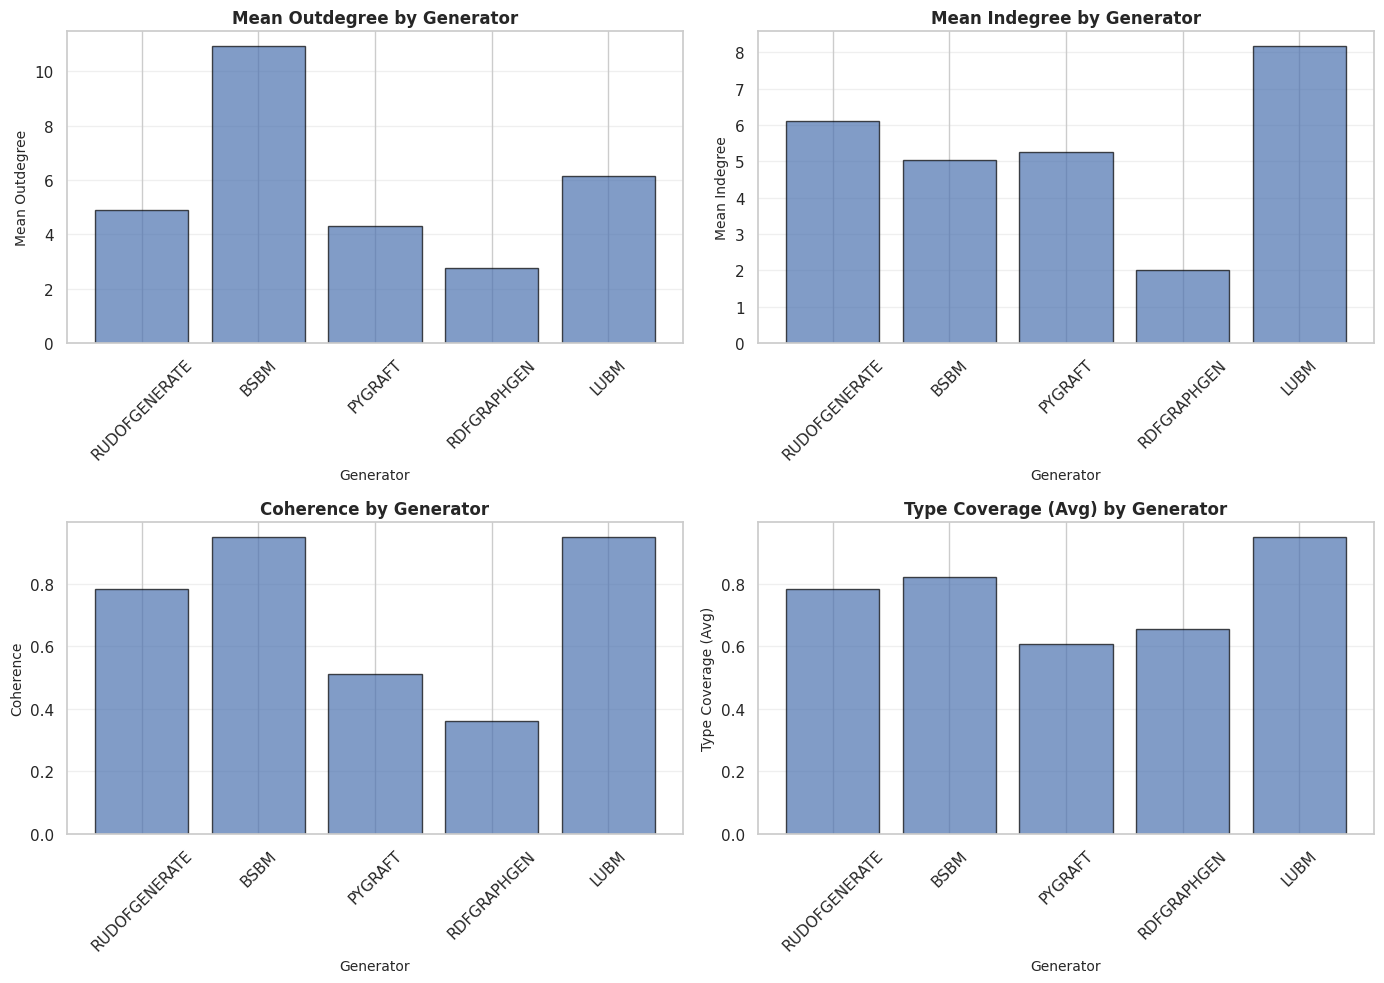

In [7]:
# Create 4 histograms for the selected metrics
metrics = [
    "Mean Outdegree",
    "Mean Indegree",
    "Coherence",
    "Type Coverage (Avg)"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Create histogram
    ax.bar(df_results['Generator'], df_results[metric], alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric} by Generator', fontsize=12, fontweight='bold')
    ax.set_xlabel('Generator', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
